#### Linear regression using python

In [17]:
import numpy as np

X = 2 * np.random.rand(100,1)
noise = np.random.randn(100,1)

y = 3*X + noise + 4

In [18]:
y

array([[ 8.20541921],
       [ 8.88698867],
       [ 8.06280078],
       [ 4.39912325],
       [ 5.67290791],
       [ 8.34060037],
       [ 4.72689936],
       [ 6.25626251],
       [ 5.28707336],
       [ 7.78491011],
       [ 4.8926287 ],
       [ 6.28947411],
       [ 5.75096934],
       [ 8.54868187],
       [ 7.71722517],
       [ 7.21810438],
       [ 9.04583156],
       [ 8.7158171 ],
       [ 5.186073  ],
       [ 5.01991891],
       [ 8.58930352],
       [ 7.0373408 ],
       [ 8.96119312],
       [ 8.05869679],
       [ 8.65296507],
       [ 8.54084054],
       [ 8.60560199],
       [ 6.09555961],
       [ 8.92919112],
       [ 7.11129304],
       [ 6.47383009],
       [ 9.34183427],
       [ 8.64979269],
       [ 4.56530325],
       [ 7.48863315],
       [ 6.05418315],
       [ 9.58353598],
       [ 6.25413972],
       [ 8.9108048 ],
       [ 8.1345417 ],
       [ 3.0402411 ],
       [ 4.92767098],
       [ 9.46197751],
       [ 5.91627551],
       [ 4.50828614],
       [ 9

In [19]:
y.shape

(100, 1)

In [20]:
shuffled_indices = np.random.permutation(100)
shuffled_indices

array([10,  4, 32, 52, 68, 82, 54, 51, 33, 45, 41, 24, 67, 38, 49, 26, 48,
       92, 71, 97, 22, 61, 20, 64, 98, 79, 39, 31, 85, 76, 21, 78,  8, 80,
        1, 44,  6, 93, 55, 89, 83, 30, 84, 34, 62, 37, 88, 35, 53, 99, 56,
       75,  3, 47, 90, 86, 12, 11, 91,  9, 59, 96,  5, 81, 25, 94, 43, 60,
       70, 57, 16, 18, 36, 50, 14, 13, 69, 58,  2, 66, 63, 73, 95, 19, 72,
       74,  7, 46, 29, 65, 15, 87, 23, 42, 27, 28, 17, 77, 40,  0],
      dtype=int32)

In [21]:
X_shuffled = X[shuffled_indices]
y_shuffled = y[shuffled_indices]

In [22]:
X_train = X_shuffled[:80]
X_test = X_shuffled[80:]

y_train = y_shuffled[:80]
y_test = y_shuffled[80:]

In [23]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(80, 1)
(20, 1)
(80, 1)
(20, 1)


In [24]:

w = 0.0
b = 0.0

alpha = 0.01
epochs = 1000

m = len(X_train)
loss = []

In [25]:
for epoch in range(epochs):
    # predicting
    y_pred = w*X_train + b
    
    #loss
    cost = np.mean((y_pred-y_train)**2) / 2
    loss.append(cost)
    
    # gradients
    gradient_w = np.mean((y_pred - y_train)*X_train)
    gradient_b = np.mean(y_pred-y_train)
    
    # updating
    w = w - (alpha*gradient_w)
    b = b - (alpha*gradient_b)
    
    
    

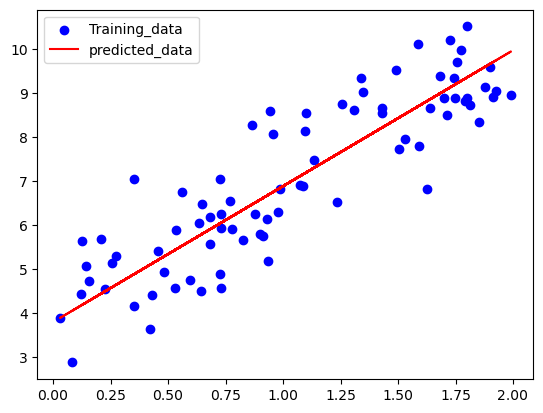

In [26]:
import matplotlib.pyplot as plt

plt.scatter(X_train, y_train, color='blue', label='Training_data')
plt.plot(X_train, y_pred, color='red', label='predicted_data')
plt.legend()
plt.show()

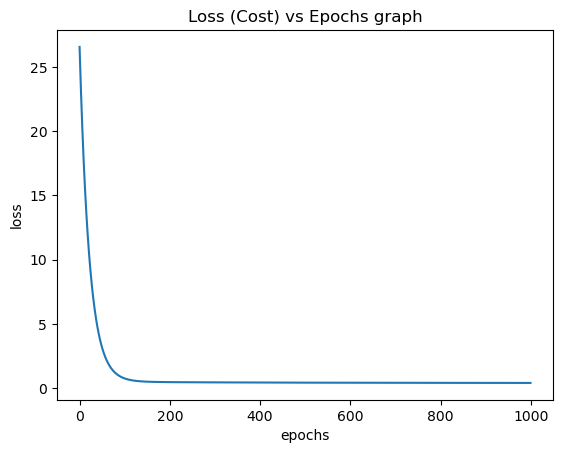

In [27]:
plt.plot(loss)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title("Loss (Cost) vs Epochs graph")
plt.show()

In [28]:
# experimenting part

def train_linear_regression(X_train, y_train, alpha, epochs):
    
    w = 0.0
    b = 0.0
    loss_history = []
    
    
    for epoch in range(epochs):
        y_pred = w * X_train + b
        cost = np.mean((y_pred - y_train) ** 2) / 2
        loss_history.append(cost)
        
        gradient_w = np.mean((y_pred - y_train) * X_train)
        gradient_b = np.mean(y_pred - y_train)
        
        w = w - (alpha * gradient_w)
        b = b - (alpha * gradient_b)
        
    
    return loss_history

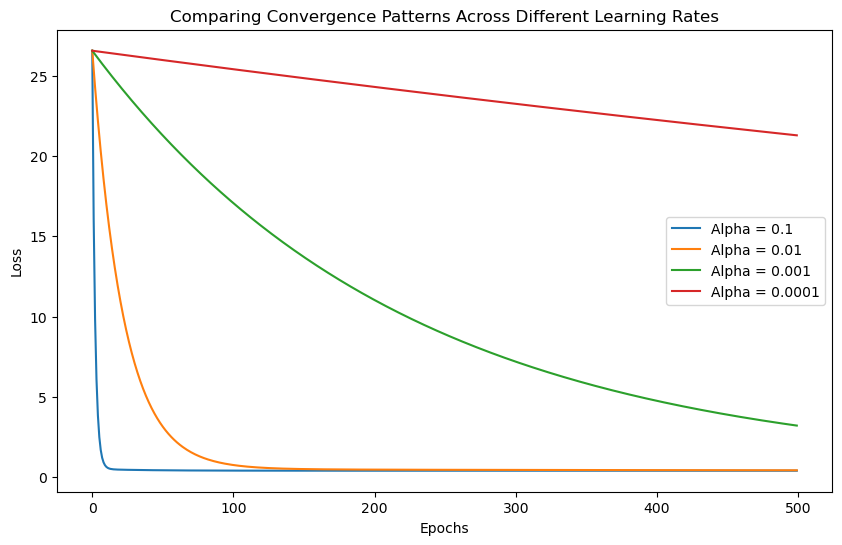

In [29]:
# now testing with different values of alpha
learning_rates = [0.1, 0.01, 0.001, 0.0001]
epochs_to_test = 500  

plt.figure(figsize=(10, 6))


for alpha in learning_rates:
    history = train_linear_regression(X_train, y_train, alpha, epochs_to_test)
    plt.plot(history, label=f'Alpha = {alpha}')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Comparing Convergence Patterns Across Different Learning Rates")
plt.legend()
plt.show()

In [30]:
def evaluate(y_actual, y_pred):
    mae = np.mean(np.abs(y_actual - y_pred))
    mse = np.mean((y_actual - y_pred) ** 2)
    rmse = np.sqrt(mse)
    
    ss_res = np.sum((y_actual - y_pred) ** 2)
    ss_tot = np.sum((y_actual - np.mean(y_actual)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")

In [32]:
y_train_pred = w * X_train + b

y_test_pred = w * X_test + b

In [34]:
print("Training Performance")
evaluate(y_train, y_train_pred)

print("\nTesting Performance")
evaluate(y_test, y_test_pred)

Training Performance
MAE: 0.7543
MSE: 0.8150
RMSE: 0.9028
R2 Score: 0.7684

Testing Performance
MAE: 0.7088
MSE: 0.8053
RMSE: 0.8974
R2 Score: 0.7668
